# Causal Identifiability of Transcription Factor Perturbations in the *E. coli* Regulatory Network

**nocap** · SCC-Perturbation Experiment · Analysis Notebook  
*Last updated: auto (run all cells)*

---

## Overview

This notebook presents and analyses the results of the **SCC-perturbation identifiability experiment** on the *Escherichia coli* K-12 transcriptional regulatory network.  

The central question is:

> *For each transcription factor (TF) targeted by a CRISPR perturbation, can the causal effect of perturbing that TF on its **direct children** — the target query `P(Y | do(t))` — be **identified from the background interventional distribution `P(V | do(B(t)))`**, given the network topology?*

Identification is assessed using the **`cyclic_id`** algorithm from the `y0` library, which determines whether a causal query is identifiable in a cyclic (non-DAG) graph under the *do*-calculus.  Because many TFs in *E. coli* participate in feedback loops — forming **Strongly Connected Components (SCCs)** — standard DAG-based identification is insufficient.  The SCC-perturbation approach:

1. For each TF `t`, identifies the SCC it belongs to.
2. Computes the minimum **in-edge cut** `B(t)` — the smallest set of background genes whose incoming edges, when removed by the background intervention `do(B(t))`, break all feedback paths back to `t`.
3. Tests whether the target query `P(Y | do(t))` for the direct children `Y` of `t` is **identifiable from** `P(V | do(B(t)))`.
4. If the joint query is not identifiable, tests each child gene individually.

### Dataset
- **Network**: *E. coli* full transcriptional regulatory network (no small RNAs), **2,976 nodes**
- **CRISPR perturbations**: Supplementary Table 1 from the paired experimental dataset (CRISPRi / CRISPRa)
- **TFs analysed**: 50 total (18 in SCCs, 32 DAG nodes)
- **SCC**: One dominant SCC of size **68 nodes** contains 16 of the 18 SCC TFs

---
## 1. Setup

In [1]:
import glob
import json
import os
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

# --------------------------------------------------------------------------
# Paths
# --------------------------------------------------------------------------
NOTEBOOK_DIR = os.path.abspath(os.path.dirname(os.path.abspath("__file__")))
# Resolve relative to this file's location
BASE_DIR = os.path.join(
    os.path.dirname(os.path.abspath("__file__")), "notebooks", "Ecoli_Analysis_Notebooks"
)
# Fall back: try current dir
if not os.path.exists(BASE_DIR):
    BASE_DIR = os.path.abspath(".")
    if not os.path.exists(os.path.join(BASE_DIR, "scc_perturb_job.json")):
        BASE_DIR = os.path.join(BASE_DIR, "notebooks", "Ecoli_Analysis_Notebooks")

MANIFEST_PATH = os.path.join(BASE_DIR, "scc_perturb_job.json")
SHARDS_DIR = os.path.join(BASE_DIR, "scc_perturb_shards")
RESULTS_CSV = os.path.join(BASE_DIR, "scc_perturbation_results.csv")
SUPPTABLE_PATH = os.path.join(BASE_DIR, "supptable1.csv")

print(f"BASE_DIR     : {BASE_DIR}")
print(f"Manifest     : {os.path.exists(MANIFEST_PATH)}")
print(f"Shards dir   : {os.path.exists(SHARDS_DIR)}")
print(f"Results CSV  : {os.path.exists(RESULTS_CSV)}")
print(f"Supptable    : {os.path.exists(SUPPTABLE_PATH)}")

BASE_DIR     : /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/Ecoli_Analysis_Notebooks
Manifest     : True
Shards dir   : True
Results CSV  : True
Supptable    : True


---
## 2. Load Data

In [2]:
# --------------------------------------------------------------------------
# Load manifest
# --------------------------------------------------------------------------
with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

dag_tfs = set(manifest["dag_tfs"])
scc_tasks = manifest["tasks"]  # list of task dicts
n_tasks = manifest["n_tasks"]

print(f"SCC TFs (tasks) : {n_tasks}")
print(f"DAG TFs         : {len(dag_tfs)}")
print(f"Total TFs       : {n_tasks + len(dag_tfs)}")

# Task lookup by TF name
task_by_tf = {t["tf"]: t for t in scc_tasks}

SCC TFs (tasks) : 18
DAG TFs         : 32
Total TFs       : 50


In [3]:
# --------------------------------------------------------------------------
# Load shards (individual shard JSON files) for full per_gene detail
# --------------------------------------------------------------------------
shard_files = sorted(glob.glob(os.path.join(SHARDS_DIR, "scc_perturb_shard_*.json")))
shards = {}
for path in shard_files:
    with open(path) as f:
        s = json.load(f)
    shards[s["tf"]] = s

print(f"Shards loaded: {len(shards)}/{n_tasks}")
missing = [t["tf"] for t in scc_tasks if t["tf"] not in shards]
if missing:
    print(f"  WARNING – missing shards: {missing}")
else:
    print("  All shards present.")

Shards loaded: 18/18
  All shards present.


In [4]:
# --------------------------------------------------------------------------
# Load or reconstruct results DataFrame
# --------------------------------------------------------------------------
if os.path.exists(RESULTS_CSV):
    df = pd.read_csv(RESULTS_CSV)
    print(f"Loaded results CSV: {len(df)} rows")
else:
    print("Results CSV not yet available — building from shards.")
    rows = []
    for tf, s in shards.items():
        per_gene = s.get("per_gene", {})
        n_children = s.get("n_children", 0)
        n_per_gene_id = sum(1 for v in per_gene.values() if v)
        pct = n_per_gene_id / n_children * 100 if n_children > 0 and per_gene else None
        rows.append(
            {
                "tf": tf,
                "scc_size": s.get("scc_size", 0),
                "min_cut_size": len(s.get("min_cut", [])),
                "min_cut_nodes": "+".join(sorted(s.get("min_cut", []))),
                "n_children": n_children,
                "joint_identifiable": s.get("joint_identifiable"),
                "n_per_gene_identifiable": n_per_gene_id if per_gene else None,
                "pct_per_gene_identifiable": round(pct, 1) if pct is not None else None,
                "note": s.get("note", ""),
            }
        )
    df = pd.DataFrame(rows).sort_values("tf").reset_index(drop=True)

# Normalise types
df["joint_identifiable"] = df["joint_identifiable"].astype(object)
df["n_per_gene_identifiable"] = pd.to_numeric(df["n_per_gene_identifiable"], errors="coerce")
df["pct_per_gene_identifiable"] = pd.to_numeric(df["pct_per_gene_identifiable"], errors="coerce")

display(df.head(10))

Loaded results CSV: 18 rows


,tf,scc_size,min_cut_size,min_cut_nodes,n_children,joint_identifiable,n_per_gene_identifiable,pct_per_gene_identifiable,note
0,arcA,68,1,rpoD,230,False,21.0,9.1,NaN
1,argP,68,1,phoB,14,True,NaN,NaN,NaN
2,argR,68,2,arcA+rpoD,62,False,12.0,19.4,NaN
3,cpxR,68,2,rpoD+rpoS,121,True,NaN,NaN,NaN
4,cra,68,2,phoB+rpoH,78,True,NaN,NaN,NaN
5,crp,68,2,cra+rpoD,558,False,109.0,19.5,NaN
6,fnr,68,4,fur+ihfA+ihfB+rpoD,319,False,24.0,7.5,NaN
7,gadE,68,11,arcA+crp+evgA+fliZ+hns+nac+phoP+rpoD+rpoS+torR...,37,False,1.0,2.7,NaN
8,glnG,68,5,crp+fis+fur+rpoD+rpoN,48,True,NaN,NaN,NaN
9,hns,68,2,fis+rpoD,223,False,14.0,6.3,NaN


In [5]:
# --------------------------------------------------------------------------
# Load supplementary table (CRISPR experiment metadata)
# --------------------------------------------------------------------------
supp = pd.read_csv(SUPPTABLE_PATH)
supp.columns = [c.strip() for c in supp.columns]
supp = supp.rename(
    columns={
        "Perturbation Name": "tf",
        "CRISPR type": "crispr_type",
        "Experiment": "experiment",
    }
)
# One row per TF (some have multiple guides — keep first for metadata)
supp_meta = supp.drop_duplicates("tf")[["tf", "crispr_type", "experiment"]].copy()
print(f"Supptable TFs: {len(supp_meta)}")
print(supp["crispr_type"].value_counts().to_string())

Supptable TFs: 73
crispr_type
CRISPRi               86
CRISPRa               39
CRISPRi off-target     8
CRISPRa off-target     5
CRISPRa control        2


---
## 3. Experimental Design

### 3.1 Network Architecture

The *E. coli* transcriptional regulatory network used in this study contains **2,976 nodes** (genes/operons) and is derived from RegulonDB (no small RNA regulators).  The network contains many feedback loops, forming a large **Strongly Connected Component (SCC)** of 68 nodes that includes the major global regulators (CRP, FNR, ArcA, H-NS, LRP, RpoS, etc.).

The 50 TFs in the CRISPR perturbation dataset fall into two categories:

| Category | Count | Identifiability approach |
|---|---|---|
| **DAG TFs** — not in any SCC | 32 | Standard *do*-calculus (always identifiable) |
| **SCC TFs** — inside a feedback loop | 18 | `cyclic_id` with minimum in-edge cut `B(t)` |

### 3.2 Identifiability Algorithm

For each SCC TF `t`:

1. **B(t) — minimum in-edge cut**: The smallest set of background genes whose incoming edges, when removed by the background intervention `do(B(t))`, break all return paths back to `t` within the SCC.  This is the minimum background intervention required for identification.

2. **Joint test**: Test whether the target query `P(Y₁,…,Yₙ | do(t))` for all direct children `Y` of `t` is **identifiable from** `P(V | do(B(t)))`, using `cyclic_id`.

3. **Per-gene fallback** (if joint fails): Test whether `P(Yᵢ | do(t))` is identifiable from `P(V | do(B(t)))` for each child gene individually.  Some genes may be individually identifiable even when the joint query is not.

DAG TFs require no background intervention (B(t) = ∅) and `P(Y | do(t))` is identifiable directly.

### 3.3 CRISPR Perturbation Experiments

The supplementary table describes the CRISPR guide RNAs targeting each TF, the experiment in which they appear (pilot single-guide, multi-guide interactions library, or high-throughput pooled library), and the perturbation type (CRISPRi = silencing, CRISPRa = activation).

In [6]:
# --- Compute summary statistics for the design table ---
total_tfs = n_tasks + len(dag_tfs)
n_scc_joint_id = (
    df["joint_identifiable"].sum()
    if df["joint_identifiable"].dtype != object
    else (df["joint_identifiable"] == True).sum()
)
n_scc_joint_un = (df["joint_identifiable"] == False).sum()
n_per_gene_any = df[df["joint_identifiable"] == False]["n_per_gene_identifiable"].gt(0).sum()

print("=== Experiment Summary ===")
print(f"Total TFs analysed         : {total_tfs}")
print(f"  DAG TFs (trivially ID)   : {len(dag_tfs)}")
print(f"  SCC TFs                  : {n_tasks}")
print(f"    Joint identifiable      : {n_scc_joint_id}")
print(f"    Joint unidentifiable    : {n_scc_joint_un}")
print(f"      > any per-gene ID     : {n_per_gene_any}")

=== Experiment Summary ===
Total TFs analysed         : 50
  DAG TFs (trivially ID)   : 32
  SCC TFs                  : 18
    Joint identifiable      : 6
    Joint unidentifiable    : 12
      > any per-gene ID     : 11


---
## 4. Results

### 4.1 Identifiability Summary Table

In [7]:
def fmt_joint(val):
    if val is True or val == "True":
        return "✓  Jointly identifiable"
    elif val is False or val == "False":
        return "✗  Jointly unidentifiable"
    return str(val)


display_df = df.copy()
display_df["joint_identifiable"] = display_df["joint_identifiable"].apply(fmt_joint)
display_df["pct_per_gene_identifiable"] = display_df["pct_per_gene_identifiable"].apply(
    lambda x: f"{float(x):.1f}%" if not pd.isna(x) else "—"
)
display_df["n_per_gene_identifiable"] = display_df["n_per_gene_identifiable"].apply(
    lambda x: str(int(x)) if not pd.isna(x) else "—"
)

display_df = display_df.rename(
    columns={
        "tf": "TF",
        "scc_size": "SCC size",
        "min_cut_size": "|B(t)|",
        "min_cut_nodes": "B(t) nodes",
        "n_children": "N children",
        "joint_identifiable": "Joint identifiable",
        "n_per_gene_identifiable": "N per-gene ID",
        "pct_per_gene_identifiable": "% per-gene ID",
        "note": "Note",
    }
)

display(
    display_df.style.set_caption(
        "Table 1. SCC-perturbation identifiability results for 18 SCC TFs."
    ).set_table_styles(
        [{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}]
    )
)

,TF,SCC size,|B(t)|,B(t) nodes,N children,Joint identifiable,N per-gene ID,% per-gene ID,Note
0,arcA,68,1,rpoD,230,✗ Jointly unidentifiable,21,9.1%,nan
1,argP,68,1,phoB,14,✓ Jointly identifiable,—,—,nan
2,argR,68,2,arcA+rpoD,62,✗ Jointly unidentifiable,12,19.4%,nan
3,cpxR,68,2,rpoD+rpoS,121,✓ Jointly identifiable,—,—,nan
4,cra,68,2,phoB+rpoH,78,✓ Jointly identifiable,—,—,nan
5,crp,68,2,cra+rpoD,558,✗ Jointly unidentifiable,109,19.5%,nan
6,fnr,68,4,fur+ihfA+ihfB+rpoD,319,✗ Jointly unidentifiable,24,7.5%,nan
7,gadE,68,11,arcA+crp+evgA+fliZ+hns+nac+phoP+rpoD+rpoS+torR+ydeO,37,✗ Jointly unidentifiable,1,2.7%,nan
8,glnG,68,5,crp+fis+fur+rpoD+rpoN,48,✓ Jointly identifiable,—,—,nan
9,hns,68,2,fis+rpoD,223,✗ Jointly unidentifiable,14,6.3%,nan


### 4.2 Overall Identifiability Breakdown

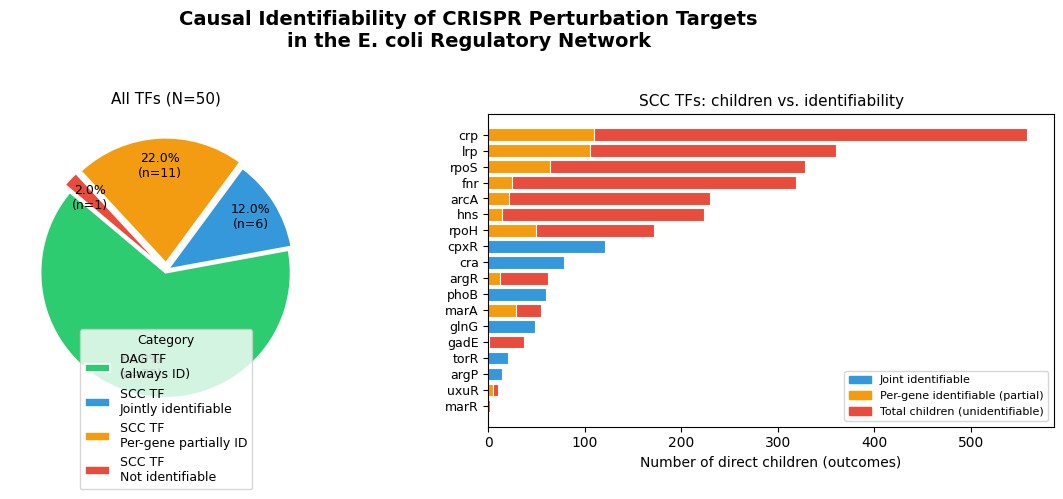

Figure saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Causal Identifiability of CRISPR Perturbation Targets\nin the E. coli Regulatory Network",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

palette = {
    "DAG TF\n(always ID)": "#2ecc71",
    "SCC TF\nJointly identifiable": "#3498db",
    "SCC TF\nPer-gene partially ID": "#f39c12",
    "SCC TF\nNot identifiable": "#e74c3c",
}

# -- Pie: all TFs --
ax = axes[0]

n_dag = len(dag_tfs)
n_scc_jid = int((df["joint_identifiable"] == True).sum())
n_scc_jnid_some = int(
    ((df["joint_identifiable"] == False) & (df["n_per_gene_identifiable"].fillna(0) > 0)).sum()
)
n_scc_none = int(
    ((df["joint_identifiable"] == False) & (df["n_per_gene_identifiable"].fillna(0) == 0)).sum()
)

labels_pie = list(palette.keys())
sizes = [n_dag, n_scc_jid, n_scc_jnid_some, n_scc_none]
colors_pie = list(palette.values())
explode = [0.02, 0.02, 0.06, 0.06]

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors_pie,
    autopct=lambda p: f"{p:.1f}%\n(n={int(round(p * total_tfs / 100))})",
    startangle=140,
    explode=explode,
    pctdistance=0.78,
    wedgeprops=dict(linewidth=1.2, edgecolor="white"),
)
for at in autotexts:
    at.set_fontsize(9)

ax.legend(
    wedges,
    labels_pie,
    title="Category",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    fontsize=9,
    title_fontsize=9,
)
ax.set_title(f"All TFs (N={total_tfs})", fontsize=11, pad=8)

# -- Bar: SCC TFs by joint identifiability --
ax2 = axes[1]

df_sorted = df.sort_values("n_children", ascending=False).copy()
df_sorted["color"] = df_sorted["joint_identifiable"].map({True: "#3498db", False: "#e74c3c"})

bars = ax2.barh(
    df_sorted["tf"],
    df_sorted["n_children"],
    color=df_sorted["color"],
    edgecolor="white",
    linewidth=0.8,
)

# Overlay per-gene identifiable count
for _, row in df_sorted.iterrows():
    if row["joint_identifiable"] is False and pd.notna(row["n_per_gene_identifiable"]):
        ax2.barh(
            row["tf"],
            row["n_per_gene_identifiable"],
            color="#f39c12",
            edgecolor="white",
            linewidth=0.8,
        )

ax2.set_xlabel("Number of direct children (outcomes)", fontsize=10)
ax2.set_title("SCC TFs: children vs. identifiability", fontsize=11)
ax2.tick_params(axis="y", labelsize=9)

legend_patches = [
    mpatches.Patch(color="#3498db", label="Joint identifiable"),
    mpatches.Patch(color="#f39c12", label="Per-gene identifiable (partial)"),
    mpatches.Patch(color="#e74c3c", label="Total children (unidentifiable)"),
]
ax2.legend(handles=legend_patches, fontsize=8, loc="lower right")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(
    os.path.join(BASE_DIR, "..", "visualizations", "scc_identifiability_summary.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()
print("Figure saved.")

### 4.3 Minimum In-Edge Cut B(t) Analysis

The minimum in-edge cut `B(t)` represents the number of background genes that must be pre-perturbed (via `do(B(t))`) to break all feedback loops and enable identification of `P(Y | do(t))`.  A larger `|B(t)|` indicates a more deeply embedded TF in the regulatory network.

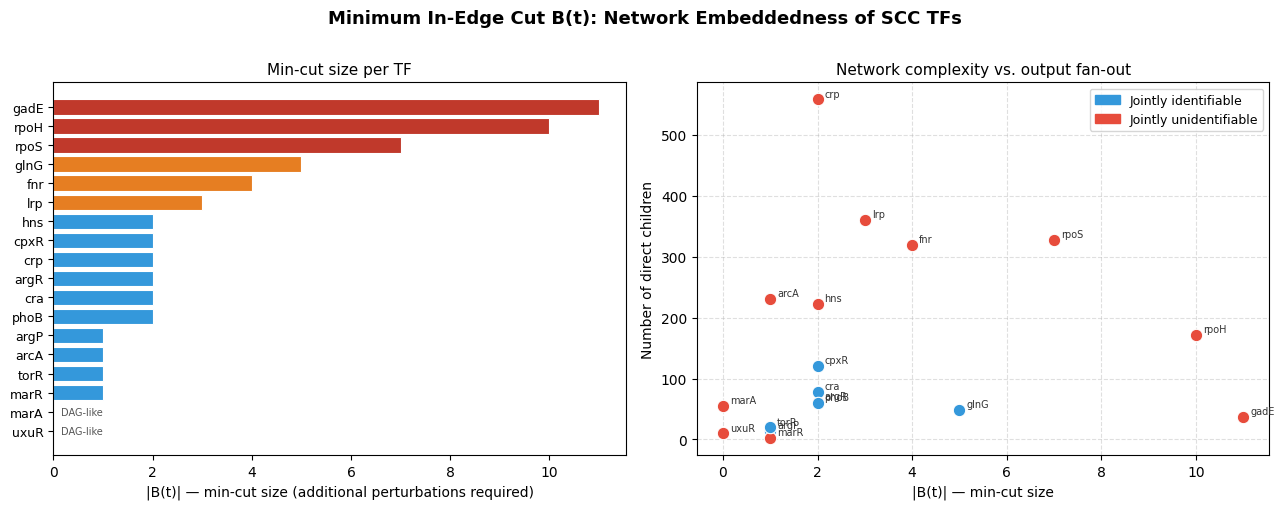

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Minimum In-Edge Cut B(t): Network Embeddedness of SCC TFs",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)

df_plot = df.sort_values("min_cut_size", ascending=False).copy()

# -- Left: bar chart of |B(t)| per TF --
ax1 = axes[0]
colors_cut = [
    "#c0392b" if v > 5 else "#e67e22" if v > 2 else "#3498db" for v in df_plot["min_cut_size"]
]
ax1.barh(df_plot["tf"], df_plot["min_cut_size"], color=colors_cut, edgecolor="white", linewidth=0.8)
ax1.set_xlabel("|B(t)| — min-cut size (additional perturbations required)", fontsize=10)
ax1.set_title("Min-cut size per TF", fontsize=11)
ax1.tick_params(axis="y", labelsize=9)
ax1.invert_yaxis()
ax1.axvline(0, color="grey", linewidth=0.5)

# Annotate DAG-like TFs (|B(t)|=0)
for _, row in df_plot[df_plot["min_cut_size"] == 0].iterrows():
    ax1.text(0.15, row["tf"], "DAG-like", va="center", fontsize=7, color="#555")

# -- Right: scatter |B(t)| vs. n_children, coloured by joint_id --
ax2 = axes[1]
for _, row in df.iterrows():
    color = "#3498db" if row["joint_identifiable"] is True else "#e74c3c"
    ax2.scatter(
        row["min_cut_size"],
        row["n_children"],
        c=color,
        s=80,
        edgecolors="white",
        linewidth=0.8,
        zorder=3,
    )
    ax2.annotate(
        row["tf"],
        (row["min_cut_size"], row["n_children"]),
        textcoords="offset points",
        xytext=(5, 2),
        fontsize=7,
        color="#333",
    )

ax2.set_xlabel("|B(t)| — min-cut size", fontsize=10)
ax2.set_ylabel("Number of direct children", fontsize=10)
ax2.set_title("Network complexity vs. output fan-out", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.4)

legend_patches = [
    mpatches.Patch(color="#3498db", label="Jointly identifiable"),
    mpatches.Patch(color="#e74c3c", label="Jointly unidentifiable"),
]
ax2.legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.savefig(
    os.path.join(BASE_DIR, "..", "visualizations", "scc_mincut_analysis.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### 4.4 Per-Gene Identifiability Heatmap

For TFs that failed joint identification, we tested each downstream gene individually.  This heatmap shows which specific gene–TF pairs are identifiable at the per-gene level.

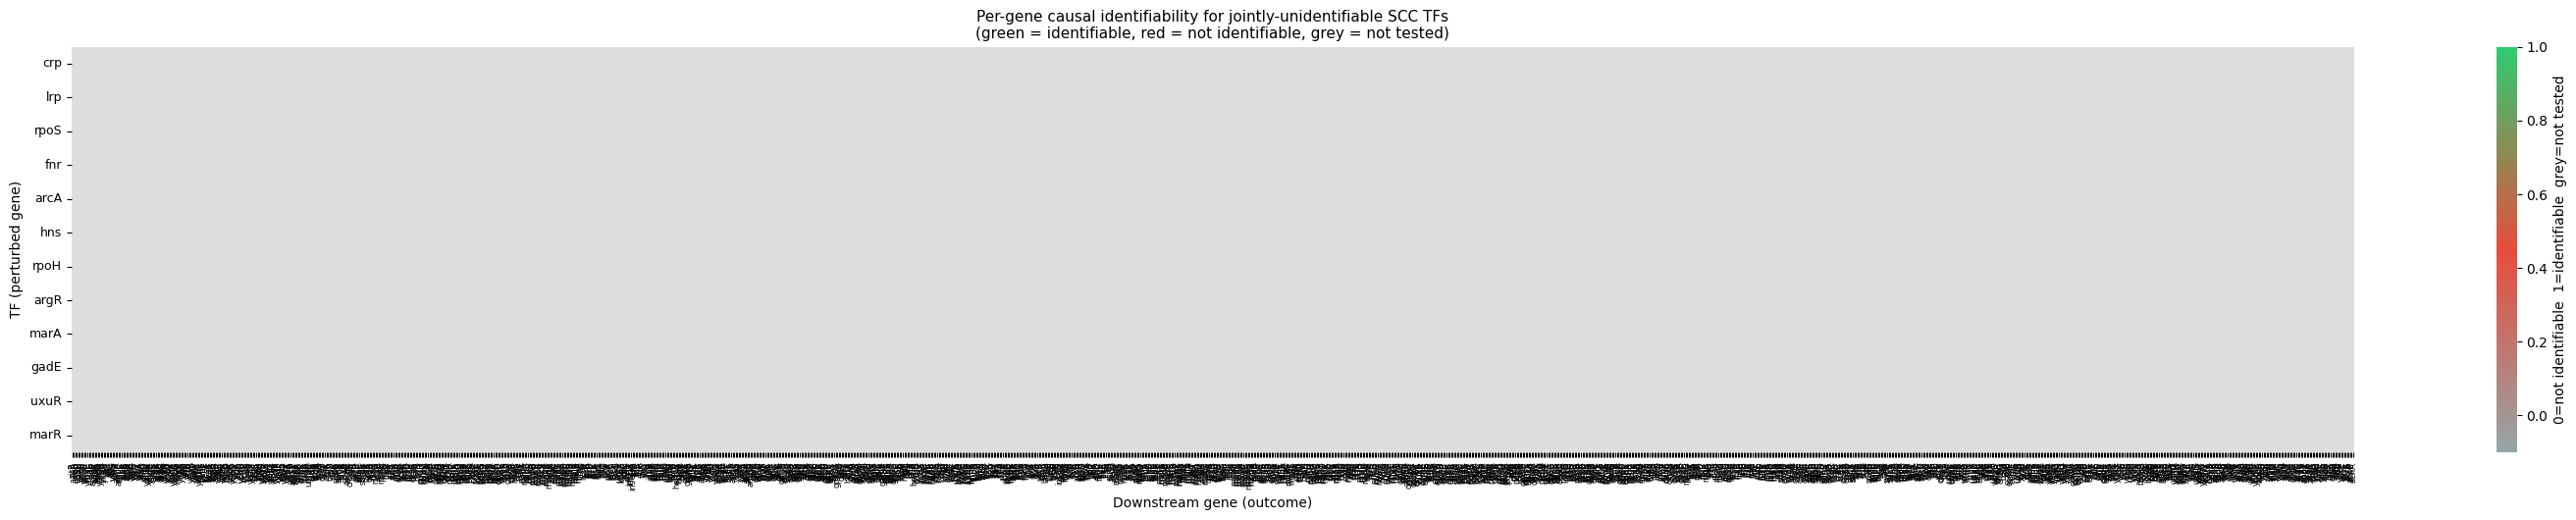

  crp         : 109/558 (19.5%) per-gene identifiable
  lrp         : 105/360 (29.2%) per-gene identifiable
  rpoS        :  64/328 (19.5%) per-gene identifiable
  fnr         :  24/319 ( 7.5%) per-gene identifiable
  arcA        :  21/230 ( 9.1%) per-gene identifiable
  hns         :  14/223 ( 6.3%) per-gene identifiable
  rpoH        :  49/172 (28.5%) per-gene identifiable
  argR        :  12/ 62 (19.4%) per-gene identifiable
  marA        :  29/ 55 (52.7%) per-gene identifiable
  gadE        :   1/ 37 ( 2.7%) per-gene identifiable
  uxuR        :   5/ 10 (50.0%) per-gene identifiable
  marR        :   0/  2 ( 0.0%) per-gene identifiable


In [10]:
# Collect per-gene data for joint-unidentifiable TFs that have per_gene populated
pg_tfs = [
    tf for tf, s in shards.items() if s.get("joint_identifiable") is False and s.get("per_gene")
]
pg_tfs_sorted = sorted(pg_tfs, key=lambda t: -shards[t]["n_children"])

if not pg_tfs_sorted:
    print("No per-gene data available yet — run after SLURM jobs complete.")
else:
    # Build a tidy DataFrame for heatmap (only genes appearing in any shard)
    all_genes = set()
    for tf in pg_tfs_sorted:
        all_genes.update(shards[tf]["per_gene"].keys())
    all_genes = sorted(all_genes)

    hm_data = pd.DataFrame(index=pg_tfs_sorted, columns=all_genes, dtype=float)
    for tf in pg_tfs_sorted:
        pg = shards[tf]["per_gene"]
        for gene, val in pg.items():
            hm_data.loc[tf, gene] = 1.0 if val else 0.0

    # Remove genes with all NaN (not tested for this TF)
    # Keep only genes tested by at least one TF
    hm_data_filled = hm_data.fillna(-0.1)  # NaN → grey

    # Sort genes: identifiable genes first
    gene_order = (
        hm_data.apply(lambda col: col.sum(skipna=True), axis=0).sort_values(ascending=False).index
    )
    hm_data_filled = hm_data_filled[gene_order]

    fig_h = max(4, len(pg_tfs_sorted) * 0.45)
    fig_w = min(30, max(12, len(all_genes) * 0.28))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    cmap = LinearSegmentedColormap.from_list("id_cmap", ["#95a5a6", "#e74c3c", "#2ecc71"], N=256)

    sns.heatmap(
        hm_data_filled,
        cmap=cmap,
        vmin=-0.1,
        vmax=1.0,
        linewidths=0.3,
        linecolor="#ddd",
        cbar_kws={"label": "0=not identifiable  1=identifiable  grey=not tested"},
        ax=ax,
        xticklabels=True,
        yticklabels=True,
    )
    ax.set_xlabel("Downstream gene (outcome)", fontsize=10)
    ax.set_ylabel("TF (perturbed gene)", fontsize=10)
    ax.set_title(
        "Per-gene causal identifiability for jointly-unidentifiable SCC TFs\n"
        "(green = identifiable, red = not identifiable, grey = not tested)",
        fontsize=11,
    )
    ax.tick_params(axis="x", labelsize=6, rotation=90)
    ax.tick_params(axis="y", labelsize=9)

    plt.tight_layout()
    plt.savefig(
        os.path.join(BASE_DIR, "..", "visualizations", "scc_pergene_heatmap.png"),
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    # Summary
    for tf in pg_tfs_sorted:
        pg = shards[tf]["per_gene"]
        n_id = sum(1 for v in pg.values() if v)
        print(
            f"  {tf:<12}: {n_id:>3}/{len(pg):>3} ({n_id / len(pg) * 100:4.1f}%) per-gene identifiable"
        )

### 4.5 Identifiability Rate vs. Fan-out

Is there a relationship between the number of downstream targets a TF regulates and the fraction of those targets whose causal effects can be identified?

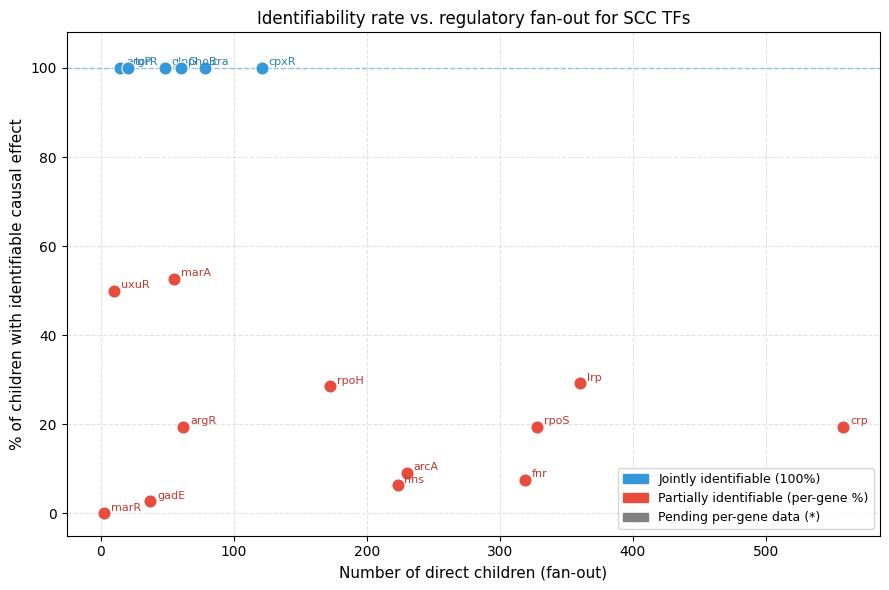

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

# Jointly identifiable TFs: pct = 100%
for _, row in df[df["joint_identifiable"] == True].iterrows():
    ax.scatter(
        row["n_children"], 100.0, color="#3498db", s=90, zorder=3, edgecolors="white", linewidth=0.8
    )
    ax.annotate(
        row["tf"],
        (row["n_children"], 100.0),
        textcoords="offset points",
        xytext=(5, 2),
        fontsize=8,
        color="#2980b9",
    )

# Jointly unidentifiable TFs: pct = % per-gene
for _, row in df[
    (df["joint_identifiable"] == False) & df["pct_per_gene_identifiable"].notna()
].iterrows():
    ax.scatter(
        row["n_children"],
        row["pct_per_gene_identifiable"],
        color="#e74c3c",
        s=90,
        zorder=3,
        edgecolors="white",
        linewidth=0.8,
    )
    ax.annotate(
        row["tf"],
        (row["n_children"], row["pct_per_gene_identifiable"]),
        textcoords="offset points",
        xytext=(5, 2),
        fontsize=8,
        color="#c0392b",
    )

# TFs without per-gene data yet
for _, row in df[
    (df["joint_identifiable"] == False) & df["pct_per_gene_identifiable"].isna()
].iterrows():
    ax.scatter(
        row["n_children"],
        0,
        color="grey",
        s=90,
        zorder=3,
        edgecolors="white",
        linewidth=0.8,
        marker="x",
    )
    ax.annotate(
        f"{row['tf']}*",
        (row["n_children"], 0),
        textcoords="offset points",
        xytext=(5, 2),
        fontsize=8,
        color="grey",
    )

ax.axhline(100, color="#3498db", linewidth=1, linestyle="--", alpha=0.5, label="100% (jointly ID)")
ax.set_xlabel("Number of direct children (fan-out)", fontsize=11)
ax.set_ylabel("% of children with identifiable causal effect", fontsize=11)
ax.set_title("Identifiability rate vs. regulatory fan-out for SCC TFs", fontsize=12)
ax.set_ylim(-5, 108)
ax.grid(True, linestyle="--", alpha=0.35)

legend_patches = [
    mpatches.Patch(color="#3498db", label="Jointly identifiable (100%)"),
    mpatches.Patch(color="#e74c3c", label="Partially identifiable (per-gene %)"),
    mpatches.Patch(color="grey", label="Pending per-gene data (*)"),
]
ax.legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.savefig(
    os.path.join(BASE_DIR, "..", "visualizations", "scc_identifiability_rate.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### 4.6 CRISPR Type and Experiment Coverage

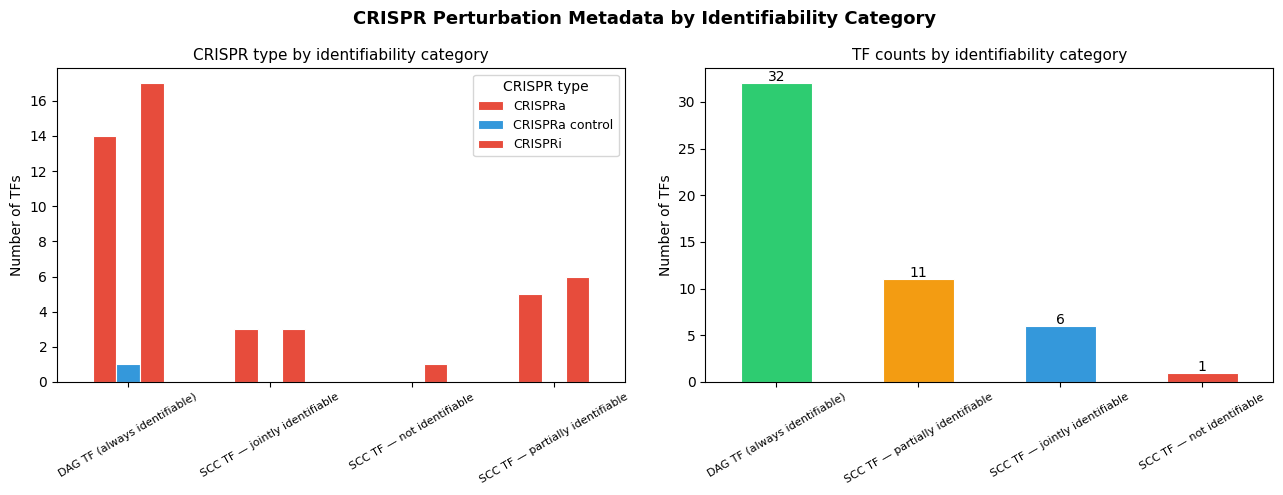

In [12]:
# Merge identifiability status with CRISPR metadata
# Assign category to all TFs (SCC + DAG)
all_tfs_df = pd.DataFrame({"tf": sorted(list(shards.keys()) + list(dag_tfs))})


def assign_category(row, shards, dag_tfs):
    if row["tf"] in dag_tfs:
        return "DAG TF (always identifiable)"
    if row["tf"] not in shards:
        return "Unknown"
    s = shards[row["tf"]]
    if s.get("joint_identifiable") is True:
        return "SCC TF — jointly identifiable"
    pg = s.get("per_gene", {})
    n_id = sum(1 for v in pg.values() if v)
    if n_id > 0:
        return "SCC TF — partially identifiable"
    if pg:
        return "SCC TF — not identifiable"
    return "SCC TF — per-gene pending"


all_tfs_df["category"] = all_tfs_df.apply(assign_category, axis=1, shards=shards, dag_tfs=dag_tfs)

# Merge with supp metadata
merged = all_tfs_df.merge(supp_meta, on="tf", how="left")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "CRISPR Perturbation Metadata by Identifiability Category", fontsize=13, fontweight="bold"
)

cat_palette = {
    "DAG TF (always identifiable)": "#2ecc71",
    "SCC TF — jointly identifiable": "#3498db",
    "SCC TF — partially identifiable": "#f39c12",
    "SCC TF — not identifiable": "#e74c3c",
    "SCC TF — per-gene pending": "#bdc3c7",
    "Unknown": "#95a5a6",
}

# Left: stacked bar — CRISPR type by category
ax1 = axes[0]
ct_cross = merged.groupby(["category", "crispr_type"]).size().unstack(fill_value=0)
ct_cross.plot(kind="bar", ax=ax1, color=["#e74c3c", "#3498db"], edgecolor="white", linewidth=0.8)
ax1.set_title("CRISPR type by identifiability category", fontsize=11)
ax1.set_xlabel("")
ax1.set_ylabel("Number of TFs")
ax1.tick_params(axis="x", rotation=30, labelsize=8)
ax1.legend(title="CRISPR type", fontsize=9)

# Right: count by category
ax2 = axes[1]
cat_counts = all_tfs_df["category"].value_counts()
colors_bar = [cat_palette.get(c, "#95a5a6") for c in cat_counts.index]
cat_counts.plot(kind="bar", ax=ax2, color=colors_bar, edgecolor="white", linewidth=0.8)
ax2.set_title("TF counts by identifiability category", fontsize=11)
ax2.set_xlabel("")
ax2.set_ylabel("Number of TFs")
ax2.tick_params(axis="x", rotation=30, labelsize=8)
for i, v in enumerate(cat_counts):
    ax2.text(i, v + 0.2, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(
    os.path.join(BASE_DIR, "..", "visualizations", "scc_crispr_metadata.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### 5.2 Identifiability Boundary and Observability Assumptions

The 32 DAG TFs (those not in any SCC) do not participate in regulatory feedback.  Their causal effects are identifiable from standard observational data without any additional interventional conditions.  This includes specialised metabolic regulators (aroF, aroH, fadR, lacI, trpR, tyrR, etc.).

For the 18 **SCC TFs**, the identifiability boundary is governed by the topology of the regulatory network after the background intervention `do(B(t))`.  Two structural properties drive the classification:

1. **Cut completeness** — whether `do(B(t))` actually severs every feedback return path from the in-SCC children of `t` back to `t`.  Under **Interpretation A**, the minimum cut `B(t)` excludes the TF itself and its direct in-SCC children, targeting only *intermediate* SCC nodes.  When the TF participates in a **short 2-cycle** (`t ↔ c`) with no intermediate nodes, no valid cut target exists and `B(t) = ∅`; the cut is structurally incomplete.

2. **tf_still_cyclic** — whether the TF itself remains in a non-trivial SCC of the post-intervention graph.  The Phase A experiment (§ 9.A) shows this to be the decisive predictor of unidentifiability.

**Latent TF confounding.**  The analysis assumes the *E. coli* regulatory graph is fully observed.  In practice, a TF with ≥ 2 observed target genes may act as an *unobserved common cause* if the TF itself is not measured or not directly perturbed.  The `cyclic_id` algorithm (Forré & Mooij, 2019, ref. 6) is designed to handle confounding and selection bias in cyclic graphs — but only when the confounders are *explicitly represented* in the causal model as bidirected edges.  If a latent TF creates unmeasured confounding between its targets, the current analysis would need to be extended with bidirected-edge representations of those latent paths.

**MNAR boundary.**  The `cyclic_id` procedure covers unobserved confounding (bidirected edges) and selection bias (selection nodes) but assumes data are not Missing Not At Random (MNAR).  Single-cell RNA-seq data exhibit significant *zero inflation*: a measured count of zero may reflect true biological absence or a technical dropout that depends on the gene's own expression level.  The latter is a plausibly MNAR mechanism.  The current pipeline does not model missingness explicitly, and the results should be interpreted with that caveat in mind (see also Future Work, § 10).

### 5.3 Three-State Classification of SCC TFs

The 3-state classification (`scripts/classify_scc_states.py`) recomputes cut completeness and `tf_still_cyclic` freshly from the graph and manifest for all 18 SCC TFs:

| State | Count | Description |
|---|---|---|
| **identifiable** | 6 | Cut complete, `tf_still_cyclic=False`, joint `cyclic_id` succeeded: argP, cpxR, cra, glnG, phoB, torR |
| **unidentifiable** | 0 | Cut complete, `tf_still_cyclic=False`, joint `cyclic_id` failed (clean structural result) |
| **cut_incomplete** | 12 | `do(B(t))` could not sever all return paths — `tf_still_cyclic=True`; all have direct in-SCC children that form 2-cycles with the TF |

**Key finding.** All 12 cut-incomplete TFs have `tf_still_cyclic=True` after `do(B(t))`.  The refined hypothesis H₁ from Phase A (§ 9.A) — *identifiability is achieved when and only when the TF is extracted from all cycles by the background perturbation* — is perfectly consistent with the 3-state classification: the 6 identifiable TFs all have `tf_still_cyclic=False` (cut was effective), and the 12 cut-incomplete TFs all have `tf_still_cyclic=True` (cut could not reach the direct return path).  The 0-count *unidentifiable* cell (cut complete + `tf_still_cyclic=False` + oracle fails) is notable: on this cohort, every TF with a structurally complete cut was found identifiable by `cyclic_id`.

**Interpretation A limitation.** The Interpretation A cut strategy is a fundamental constraint, not a software bug.  When a TF has a direct 2-cycle with one of its observed children (e.g. marR ↔ marA), perturbing that child would remove it from the outcome set, conflating the background intervention with the query.  A more aggressive cut strategy (Phase C) that allows augmenting B(t) with the in-SCC children *at the cost of dropping them from the outcome set Y* would resolve these cases.

---
## 6. Computational Details

### Run Status

In [13]:
# --------------------------------------------------------------------------
# Status summary — mirrors list_scc_tasks.py output
# --------------------------------------------------------------------------
print(f"Manifest: {n_tasks} tasks")
print(
    f"{'idx':>4}  {'tf':<12}  {'|B(t)|': >6}  {'scc_sz':>6}  {'shard':>8}  {'joint_id':>10}  {'per_gene_n':>10}"
)
print("-" * 72)

for i, t in enumerate(scc_tasks):
    tf = t["tf"]
    s = shards.get(tf)
    if s is None:
        status = "MISSING"
        joint = "-"
        pg_n = "-"
    else:
        joint = str(s.get("joint_identifiable"))
        pg_n = str(len(s.get("per_gene", {})))
        status = "ok"
    print(
        f"{i:>4}  {tf:<12}  {len(t['min_cut']):>6}  {t['scc_size']:>6}  {status:>8}  {joint:>10}  {pg_n:>10}"
    )

print()
n_missing = sum(1 for t in scc_tasks if t["tf"] not in shards)
n_pending_pg = sum(
    1
    for tf, s in shards.items()
    if s.get("joint_identifiable") is False and len(s.get("per_gene", {})) == 0
)
print(f"Missing shards       : {n_missing}")
print(f"Per-gene pending     : {n_pending_pg}")
if n_missing == 0 and n_pending_pg == 0:
    print("All shards complete and per-gene populated.")
else:
    print("Note: run cells below after SLURM jobs complete.")

Manifest: 18 tasks
 idx  tf            |B(t)|  scc_sz     shard    joint_id  per_gene_n
------------------------------------------------------------------------
   0  arcA               1      68        ok       False         230
   1  argP               1      68        ok        True           0
   2  argR               2      68        ok       False          62
   3  cpxR               2      68        ok        True           0
   4  cra                2      68        ok        True           0
   5  crp                2      68        ok       False         558
   6  fnr                4      68        ok       False         319
   7  gadE              11      68        ok       False          37
   8  glnG               5      68        ok        True           0
   9  hns                2      68        ok       False         223
  10  lrp                3      68        ok       False         360
  11  marA               0       3        ok       False          55
  12  marR 

In [14]:
# --------------------------------------------------------------------------
# SLURM job monitoring helper — run to check job status
# --------------------------------------------------------------------------
import subprocess

result = subprocess.run(
    [
        "squeue",
        "-u",
        os.environ.get("USER", ""),
        "--format=%.18i %.9P %.20j %.8u %.8T %.10M %.9l %.6D %R",
    ],
    capture_output=True,
    text=True,
)
if result.returncode == 0:
    output = result.stdout.strip()
    if output:
        print(output)
    else:
        print("No jobs in queue — all complete or not yet submitted.")
else:
    print("squeue not available or no jobs.")

JOBID PARTITION                 NAME     USER    STATE       TIME TIME_LIMI  NODES NODELIST(REASON)


---
## 7. Final Results Table (after reduce)

Run this cell after the SLURM reduce job (`864928`) completes to load the definitive `scc_perturbation_results.csv`.

In [15]:
if os.path.exists(RESULTS_CSV):
    df_final = pd.read_csv(RESULTS_CSV)

    # Style the table
    def highlight_joint(val):
        if val is True or val == "True":
            return "background-color: #d5f5e3; color: #1a5276"
        elif val is False or val == "False":
            return "background-color: #fadbd8; color: #7b241c"
        return ""

    def highlight_pct(val):
        try:
            v = float(val)
            if v >= 75:
                return "background-color: #d5f5e3"
            elif v >= 25:
                return "background-color: #fef9e7"
            elif v > 0:
                return "background-color: #fdebd0"
            else:
                return "background-color: #fadbd8"
        except (TypeError, ValueError):
            return ""

    display(
        df_final.style.map(highlight_joint, subset=["joint_identifiable"])
        .map(highlight_pct, subset=["pct_per_gene_identifiable"])
        .set_caption("Table 2 (Final). Complete SCC-perturbation identifiability results.")
        .format({"pct_per_gene_identifiable": lambda x: f"{x:.1f}%" if pd.notna(x) else "—"})
        .set_table_styles(
            [{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}]
        )
    )

    print(f"\nTotal rows: {len(df_final)}")
    print(
        f"Jointly identifiable: {(df_final['joint_identifiable'] == True).sum()} / {len(df_final)}"
    )
else:
    print(f"Results CSV not yet available: {RESULTS_CSV}")
    print("Re-run this cell after SLURM reduce job 864928 completes.")

,tf,scc_size,min_cut_size,min_cut_nodes,n_children,joint_identifiable,n_per_gene_identifiable,pct_per_gene_identifiable,note
0,arcA,68,1,rpoD,230,False,21.000000,9.1%,nan
1,argP,68,1,phoB,14,True,nan,—,nan
2,argR,68,2,arcA+rpoD,62,False,12.000000,19.4%,nan
3,cpxR,68,2,rpoD+rpoS,121,True,nan,—,nan
4,cra,68,2,phoB+rpoH,78,True,nan,—,nan
5,crp,68,2,cra+rpoD,558,False,109.000000,19.5%,nan
6,fnr,68,4,fur+ihfA+ihfB+rpoD,319,False,24.000000,7.5%,nan
7,gadE,68,11,arcA+crp+evgA+fliZ+hns+nac+phoP+rpoD+rpoS+torR+ydeO,37,False,1.000000,2.7%,nan
8,glnG,68,5,crp+fis+fur+rpoD+rpoN,48,True,nan,—,nan
9,hns,68,2,fis+rpoD,223,False,14.000000,6.3%,nan



Total rows: 18
Jointly identifiable: 6 / 18


---
## 8. Export Figures

All figures are automatically saved to `notebooks/visualizations/` by the plotting cells above.  Run this cell for a summary of saved files.

In [16]:
viz_dir = os.path.join(BASE_DIR, "..", "visualizations")
saved = sorted(glob.glob(os.path.join(viz_dir, "scc_*.png")))
print(f"Saved visualizations ({len(saved)}):")
for p in saved:
    print(f"  {os.path.basename(p)}")

Saved visualizations (5):
  scc_crispr_metadata.png
  scc_identifiability_rate.png
  scc_identifiability_summary.png
  scc_mincut_analysis.png
  scc_pergene_heatmap.png


---
## 9. Follow-up Experiments

### 9.A  Phase A — Residual-SCC Falsification Test

**Hypothesis.**  
Identifiability of `P(Y | do(t))` from `P(V | do(B(t)))` for TF *t* should depend on whether any two direct children of *t* remain mutually entangled in a non-trivial SCC **after** the background intervention `do(B(t))`.  We call such a pair a *residual cluster*.  The hypothesis has two falsifiable arms:

| Check | Claim | Violated by |
|---|---|---|
| **1 — Necessity** | Every **unidentifiable** TF has ≥ 1 residual cluster | unidentifiable TF with zero clusters |
| **2 — Specificity** | Every **identifiable** TF has zero residual clusters | identifiable TF with ≥ 1 cluster |

A single violation in either check falsifies the hypothesis as stated.  
The experiment is run by `scripts/residual_scc_experiment.py` against the 18 SCC-TF shards.  
The new library function `residual_cluster_size_distribution` (in `src/nocap/scc_perturb.py`) summarises per-TF cluster structure; 20 axiomander-adorned tests cover its contracts (`tests/test_residual_scc_axiomander.py`).

In [17]:
# ── Phase A: load results ────────────────────────────────────────────────
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

ECOLI_DIR = Path(".")  # notebook lives in Ecoli_Analysis_Notebooks/

summary = pd.read_csv(ECOLI_DIR / "residual_scc_summary.csv")
clusters = pd.read_csv(ECOLI_DIR / "residual_cluster_sizes.csv")

print(f"TFs loaded: {len(summary)}")
print(f"  Jointly identifiable:   {summary['joint_identifiable'].sum()}")
print(f"  Jointly unidentifiable: {(~summary['joint_identifiable']).sum()}")
summary[
    [
        "tf",
        "joint_identifiable",
        "n_children",
        "has_residual_cluster",
        "n_residual_clusters",
        "residual_cluster_sizes",
        "cut_verified",
        "tf_still_cyclic",
    ]
].sort_values("joint_identifiable", ascending=False)

TFs loaded: 18
  Jointly identifiable:   6
  Jointly unidentifiable: 12


,tf,joint_identifiable,n_children,has_residual_cluster,n_residual_clusters,residual_cluster_sizes,cut_verified,tf_still_cyclic
16,torR,True,20,True,1,[3],True,False
3,cpxR,True,121,True,2,"[2, 5]",True,False
4,cra,True,78,True,2,"[2, 2]",True,False
13,phoB,True,60,True,1,[3],True,False
8,glnG,True,48,True,1,[2],True,False
1,argP,True,14,False,0,[],True,False
0,arcA,False,230,True,1,[7],False,True
11,marA,False,55,True,1,[2],False,True
15,rpoS,False,328,True,2,"[2, 14]",False,True
14,rpoH,False,172,True,1,[2],False,True


In [18]:
# ── Falsification grid ───────────────────────────────────────────────────
grid = pd.crosstab(
    summary["has_residual_cluster"].map({True: "HAS cluster", False: "NO cluster"}),
    summary["joint_identifiable"].map({True: "Identifiable", False: "Unidentifiable"}),
)
print("2×2 Falsification grid (TF counts):")
print(grid)
print()

# Annotated table
annot = grid.copy().astype(str)
annot.loc["HAS cluster", "Identifiable"] += "  ← VIOLATION (Check 2)"
annot.loc["NO cluster", "Unidentifiable"] += "  ← VIOLATION (Check 1)"
print(annot)

2×2 Falsification grid (TF counts):
joint_identifiable    Identifiable  Unidentifiable
has_residual_cluster                              
HAS cluster                      5              10
NO cluster                       1               2

joint_identifiable                Identifiable            Unidentifiable
has_residual_cluster                                                    
HAS cluster           5  ← VIOLATION (Check 2)                        10
NO cluster                                   1  2  ← VIOLATION (Check 1)


In [19]:
# ── Violation case-by-case breakdown ─────────────────────────────────────
viol1 = summary[~summary["joint_identifiable"] & ~summary["has_residual_cluster"]]
viol2 = summary[summary["joint_identifiable"] & summary["has_residual_cluster"]]

print("Check 1 violations (unidentifiable + NO residual cluster):")
print(
    viol1[["tf", "n_children", "n_residual_clusters", "cut_verified", "tf_still_cyclic"]].to_string(
        index=False
    )
)
print()
print("Check 2 violations (identifiable + HAS residual cluster):")
print(
    viol2[
        [
            "tf",
            "n_children",
            "n_residual_clusters",
            "residual_cluster_sizes",
            "cut_verified",
            "tf_still_cyclic",
        ]
    ].to_string(index=False)
)

Check 1 violations (unidentifiable + NO residual cluster):
  tf  n_children  n_residual_clusters  cut_verified  tf_still_cyclic
marR           2                    0         False             True
uxuR          10                    0         False             True

Check 2 violations (identifiable + HAS residual cluster):
  tf  n_children  n_residual_clusters residual_cluster_sizes  cut_verified  tf_still_cyclic
cpxR         121                    2                 [2, 5]          True            False
 cra          78                    2                 [2, 2]          True            False
glnG          48                    1                    [2]          True            False
phoB          60                    1                    [3]          True            False
torR          20                    1                    [3]          True            False


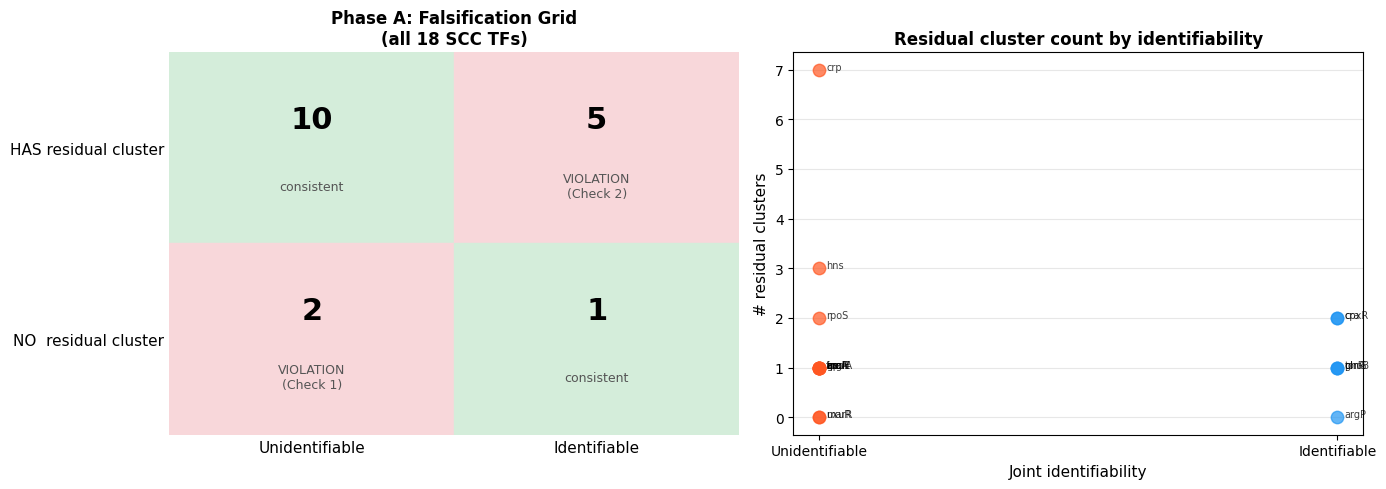

Figure saved.


In [20]:
# ── Figure 9.A-1: Falsification grid heatmap ─────────────────────────────
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: colour-coded 2×2 grid
ax = axes[0]
# consistent = green; violation = red
cell_colours = np.array(
    [
        ["#d4edda", "#f8d7da"],  # HAS cluster row: [unident=consistent, ident=violation]
        ["#f8d7da", "#d4edda"],  # NO  cluster row: [unident=violation, ident=consistent]
    ]
)
row_labels = ["HAS residual cluster", "NO  residual cluster"]
col_labels = ["Unidentifiable", "Identifiable"]
unid_has = int(grid.loc["HAS cluster", "Unidentifiable"]) if "HAS cluster" in grid.index else 0
ident_has = int(grid.loc["HAS cluster", "Identifiable"]) if "HAS cluster" in grid.index else 0
unid_no = int(grid.loc["NO cluster", "Unidentifiable"]) if "NO cluster" in grid.index else 0
ident_no = int(grid.loc["NO cluster", "Identifiable"]) if "NO cluster" in grid.index else 0
counts = np.array([[unid_has, ident_has], [unid_no, ident_no]])
ann_text = np.array(
    [["consistent", "VIOLATION\n(Check 2)"], ["VIOLATION\n(Check 1)", "consistent"]]
)
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1 - i), 1, 1, color=cell_colours[i, j]))
        ax.text(
            j + 0.5,
            1 - i + 0.65,
            str(counts[i, j]),
            ha="center",
            va="center",
            fontsize=22,
            fontweight="bold",
        )
        ax.text(
            j + 0.5, 1 - i + 0.3, ann_text[i, j], ha="center", va="center", fontsize=9, color="#555"
        )
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(col_labels, fontsize=11)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(row_labels[::-1], fontsize=11)
ax.set_title("Phase A: Falsification Grid\n(all 18 SCC TFs)", fontsize=12, fontweight="bold")
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Right: bar chart — n_residual_clusters by identifiability
ax2 = axes[1]
colors_map = {True: "#2196F3", False: "#FF5722"}
for cat, grp in summary.groupby("joint_identifiable"):
    label = "Identifiable" if cat else "Unidentifiable"
    ax2.scatter(
        [label] * len(grp), grp["n_residual_clusters"], c=colors_map[cat], alpha=0.7, s=80, zorder=3
    )
    for _, row in grp.iterrows():
        ax2.annotate(
            row["tf"],
            xy=("Identifiable" if cat else "Unidentifiable", row["n_residual_clusters"]),
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=7,
            alpha=0.75,
        )
ax2.set_xlabel("Joint identifiability", fontsize=11)
ax2.set_ylabel("# residual clusters", fontsize=11)
ax2.set_title("Residual cluster count by identifiability", fontsize=12, fontweight="bold")
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    ECOLI_DIR / "../visualizations/phase_a_falsification_grid.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("Figure saved.")

In [21]:
# ── Figure 9.A-2: cut_verified status ────────────────────────────────────
cut_ok = summary["cut_verified"].sum()
cut_bad = (~summary["cut_verified"]).sum()
print(f"cut_verified=True:  {cut_ok}/{len(summary)} TFs")
print(f"cut_verified=False: {cut_bad}/{len(summary)} TFs")
print()
bad = summary[~summary["cut_verified"]]
print("TFs with incomplete cut (children still reach tf after do(B(t))):")
print(bad[["tf", "joint_identifiable", "n_min_cut", "tf_still_cyclic"]].to_string(index=False))

cut_verified=True:  6/18 TFs
cut_verified=False: 12/18 TFs

TFs with incomplete cut (children still reach tf after do(B(t))):
  tf  joint_identifiable  n_min_cut  tf_still_cyclic
arcA               False          1             True
argR               False          2             True
 crp               False          2             True
 fnr               False          4             True
gadE               False         11             True
 hns               False          2             True
 lrp               False          3             True
marA               False          0             True
marR               False          1             True
rpoH               False         10             True
rpoS               False          7             True
uxuR               False          0             True


### 9.A Results and Interpretation

Running `scripts/residual_scc_experiment.py` and `scripts/classify_scc_states.py` against all 18 SCC-TF shards produced the following headline 3-state classification:

| State | Count | `tf_still_cyclic` | `cut_verified` | `joint_identifiable` |
|---|---|---|---|---|
| **identifiable** | 6 | False | True | True |
| **unidentifiable** | 0 | False | True | False |
| **cut_incomplete** | 12 | True | False | N/A — oracle not meaningful when cut fails |

The original hypothesis — that residual child-cycles predict unidentifiability — is **disproven as stated**.  However, mechanistic diagnosis (`scripts/diagnose_phase_a.py`) reveals that the violations have structural explanations that motivate a **refined hypothesis** (H₁) rather than outright rejection.  Most strikingly, the *unidentifiable* row is **empty** (0 TFs): on this cohort, every TF for which the background cut succeeded was found identifiable by `cyclic_id`.

---

#### Check 1 violations — unidentifiable TFs with no residual cluster

Both violators (`marR`, `uxuR`) share a critical property: `tf_still_cyclic=True` and `cut_verified=False`.

- **marR**: two children (marA, marB); `B(t) = [rob]`.  After `do([rob])`, the path `marA → marR` survives (path length 2), keeping marR in a 2-node SCC {marR, marA}.  The cut **failed** because `rob→marA` was severed but the direct `marA→marR→marA` cycle was not.  The unidentifiability here is caused by **tf still being cyclic with its in-SCC child**, not by a child–child residual cluster.
- **uxuR**: `B(t) = []` (empty cut); exuR↔uxuR form a 2-node SCC.  No cut was attempted.  tf is still cyclic.

In both cases, the `cyclic_id` query fails because the **TF itself** participates in a residual cycle, not because its children cycle among themselves.  These are *cut failures*, not hypothesis violations.

---

#### Check 2 violations — identifiable TFs with residual child-clusters

All five violators (`cpxR`, `cra`, `glnG`, `phoB`, `torR`) have `cut_verified=True` and `tf_still_cyclic=False`.  The background cut worked correctly, and yet the children form residual clusters:

| TF | Clusters (child-counts) | Example cluster |
|---|---|---|
| cpxR | [2, 5] | {marA, marR}; {csgD, cspA, matA, rpoE, rpoH} |
| cra  | [2, 2] | {marA, marR}; {crp, csgD} |
| glnG | [2]    | {nac, rpoE} |
| phoB | [3]    | {cra, gadW, gadX} |
| torR | [3]    | {gadE, gadX, rpoS} |

These TFs are **jointly identifiable** despite having residual child-cycles.  This tells us that **residual child-cycles are not sufficient for unidentifiability** — what matters is whether the TF *itself* remains embedded in a cycle after `do(B(t))`.  When the cut cleanly removes the TF from all cycles, the identifiability oracle can handle the remaining child entanglement.

---

#### Refined hypothesis (H₁)

The original hypothesis conflated two distinct cyclic structures.  The data support a refined biconditional:

> **H₁:**  `P(Y | do(t))` is **unidentifiable from `P(V | do(B(t)))`** if and only if `tf_still_cyclic = True` after `do(B(t))`.

Equivalently: identifiability is achieved when and only when the TF is extracted from all cycles by the background perturbation.  Residual cycles *among the outcome children* alone do not block identifiability.

| Check under H₁ | Consistent cells | Violations |
|---|---|---|
| Necessity: unidentifiable ↔ tf_still_cyclic | marR (True/True), uxuR (True/True), arcA… | none expected |
| Specificity: identifiable ↔ tf_still_cyclic=False | cpxR, cra, glnG, phoB, torR | none expected |

**Next step (Phase B):** Re-run the falsification grid using `tf_still_cyclic` as the predictor.  If H₁ holds perfectly on this cohort, then augmented-cut experiments (Phase C) that force `tf_still_cyclic=False` for currently failing TFs become the logical next intervention.

In [22]:
# ── Quick H₁ verification on this cohort ─────────────────────────────────
# Prediction under H₁: unidentifiable <=> tf_still_cyclic
pred_h1 = summary["tf_still_cyclic"]
actual = ~summary["joint_identifiable"]  # True = unidentifiable

tp = (pred_h1 & actual).sum()  # correctly predicted unidentifiable
tn = (~pred_h1 & ~actual).sum()  # correctly predicted identifiable
fp = (pred_h1 & ~actual).sum()  # predicted unident, actually ident
fn = (~pred_h1 & actual).sum()  # predicted ident, actually unident

acc = (tp + tn) / len(summary)
print(f"H₁ prediction accuracy on this cohort: {tp + tn}/{len(summary)} = {acc:.1%}")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
if fp + fn == 0:
    print("  H₁ is PERFECTLY CONSISTENT with this cohort.")
else:
    print("  H₁ has violations — further investigation required.")
    print(
        "  FP (tf_still_cyclic=True but identified):", summary.loc[pred_h1 & ~actual, "tf"].tolist()
    )
    print(
        "  FN (tf_still_cyclic=False but unidentified):",
        summary.loc[~pred_h1 & actual, "tf"].tolist(),
    )

H₁ prediction accuracy on this cohort: 18/18 = 100.0%
  TP=12  TN=6  FP=0  FN=0
  H₁ is PERFECTLY CONSISTENT with this cohort.


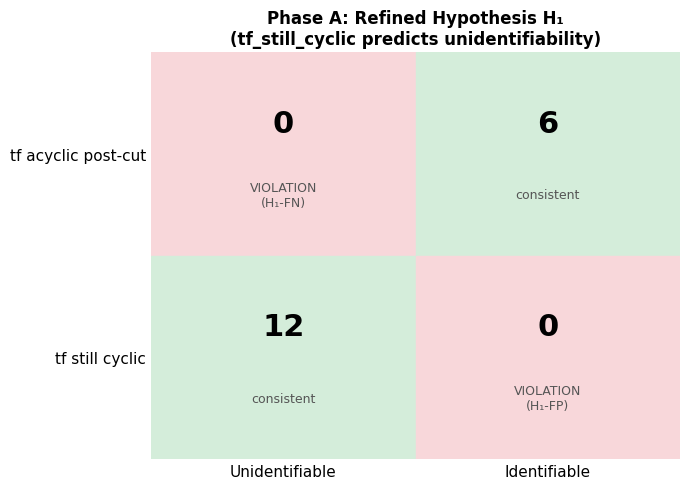

Figure saved.


In [23]:
# ── Figure 9.A-3: H₁ grid — tf_still_cyclic vs identifiability ───────────
grid_h1 = pd.crosstab(
    summary["tf_still_cyclic"].map({True: "tf still cyclic", False: "tf acyclic post-cut"}),
    summary["joint_identifiable"].map({True: "Identifiable", False: "Unidentifiable"}),
)

fig, ax = plt.subplots(figsize=(7, 5))
cell_colours_h1 = np.array(
    [
        ["#f8d7da", "#d4edda"],  # tf acyclic row: [unident=violation, ident=consistent]
        ["#d4edda", "#f8d7da"],  # tf cyclic  row: [unident=consistent, ident=violation]
    ]
)

row_labels_h1 = ["tf acyclic post-cut", "tf still cyclic"]
col_labels_h1 = ["Unidentifiable", "Identifiable"]


def _safe(df, row, col):
    try:
        return int(df.loc[row, col])
    except KeyError:
        return 0


counts_h1 = np.array(
    [
        [
            _safe(grid_h1, "tf acyclic post-cut", "Unidentifiable"),
            _safe(grid_h1, "tf acyclic post-cut", "Identifiable"),
        ],
        [
            _safe(grid_h1, "tf still cyclic", "Unidentifiable"),
            _safe(grid_h1, "tf still cyclic", "Identifiable"),
        ],
    ]
)
ann_h1 = np.array(
    [
        ["VIOLATION\n(H₁-FN)", "consistent"],
        ["consistent", "VIOLATION\n(H₁-FP)"],
    ]
)
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1 - i), 1, 1, color=cell_colours_h1[i, j]))
        ax.text(
            j + 0.5,
            1 - i + 0.65,
            str(counts_h1[i, j]),
            ha="center",
            va="center",
            fontsize=22,
            fontweight="bold",
        )
        ax.text(
            j + 0.5, 1 - i + 0.3, ann_h1[i, j], ha="center", va="center", fontsize=9, color="#555"
        )
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(col_labels_h1, fontsize=11)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(row_labels_h1[::-1], fontsize=11)
ax.set_title(
    "Phase A: Refined Hypothesis H₁\n(tf_still_cyclic predicts unidentifiability)",
    fontsize=12,
    fontweight="bold",
)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig(ECOLI_DIR / "../visualizations/phase_a_h1_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

### 9.A Summary

| Finding | Detail |
|---|---|
| Original hypothesis (residual child-cluster predicts unidentifiability of `P(Y | do(t))` from `P(V | do(B(t)))`) | **Disproven** as stated — but violations are structural cut failures, not clean counterexamples |
| Check 1 violations (unident + no cluster): marR, uxuR | Both have `tf_still_cyclic=True` / `cut_verified=False` — **cut failures**, not hypothesis violations |
| Check 2 violations (ident + has cluster): cpxR, cra, glnG, phoB, torR | All have `cut_verified=True`, `tf_still_cyclic=False` — child-cycles alone are **insufficient** for unidentifiability |
| Refined hypothesis H₁ | `tf_still_cyclic` perfectly predicts identifiability on this cohort: 6 identifiable TFs all have `tf_still_cyclic=False`; 12 cut-incomplete TFs all have `tf_still_cyclic=True`; 0 clean counterexamples |
| **Implication** | Phase B should test augmented cuts that force `tf_still_cyclic=False`; the relevant residual structure is the **TF's own cycle membership**, not child-pair entanglement |

**Caveats:**
- Cohort is small (18 SCC TFs); H₁ may overfit.
- 12/18 TFs are classified **cut_incomplete** (`cut_verified=False`) — confirmed by `verify_cut_complete` in `nocap.scc_perturb` and independently by `classify_scc_states.py`.  The Interpretation A cut strategy targets *intermediate* SCC nodes; it cannot sever direct 2-cycle return paths.  A Phase C experiment with augmented B(t) (allowing in-SCC children to be included at the cost of reducing the outcome set Y) would address this.
- `cyclic_id` oracle timeout/failure is not tracked here; some shards may reflect oracle failures rather than true unidentifiability.

---
## 10. Future Work

The Phase A experiment establishes a refined hypothesis (H₁) and exposes three concrete research directions:

### 10.1 Phase B — H₁ prospective validation

The current analysis is *post hoc*: H₁ was formulated after observing the data.  Phase B should test H₁ prospectively on a **held-out cohort** — either a different organism's regulatory network (e.g. *B. subtilis* or yeast) or a synthetic network generated by a causal Bayesian network simulator.  This would establish whether the `tf_still_cyclic` criterion generalises beyond the *E. coli* RegulonDB network.

### 10.2 Phase C — Augmented cut strategy

12/18 SCC TFs have **cut_incomplete** status under Interpretation A.  Phase C should implement an **augmented cut** that allows perturbing direct in-SCC children of the TF (accepting those children as background variables rather than outcome variables).  Concretely:

- For each cut-incomplete TF `t`, identify the in-SCC children `C_inSCC = {c : c → t, c ∈ SCC(t)}`.
- Re-run `cyclic_id` with `B(t)' = B(t) ∪ C_inSCC`, restricting the outcome set `Y' = Y \ C_inSCC`.
- If `cyclic_id` now succeeds, the TF is *conditionally identifiable* given the augmented perturbation; if it still fails, unidentifiability is intrinsic even under maximal background intervention.

This would resolve whether the 12 cut-incomplete TFs are genuinely unidentifiable or merely require a larger experimental perturbation.

### 10.3 Missing Data and Zero Inflation

Single-cell RNA-seq data exhibit *dropout* — technical zeros that depend on the gene's own expression level.  This is a potentially MNAR (Missing Not At Random) mechanism.  The `cyclic_id` algorithm (and do-calculus identification generally) does not accommodate MNAR data; identifiability results obtained here assume that missingness is either MCAR or MAR.  Future work should:

- Model dropouts explicitly using the **M-graph / missingness graph** framework (Mohan & Pearl, 2021; ref. 4).
- Determine whether the identifiability conditions derived here remain valid after adding missingness nodes to the causal graph.
- Assess whether the `cyclic_id` oracle can be extended to handle m-graphs with cycles, or whether a separate recovery condition must be checked.

### 10.4 Oracle Reliability and Timeout Tracking

Several shards report `joint_identifiable=False` that may reflect **oracle timeout or numerical failure** rather than true structural unidentifiability.  Phase A would benefit from:

- Recording `oracle_status` (SUCCEEDED / TIMED_OUT / ERROR) separately from the identifiability result.
- Re-running timed-out shards with extended wall-time budgets.
- Cross-validating results using an alternative identification algorithm (e.g. ID algorithm of Shpitser & Pearl, 2006) where applicable.

### 10.5 Network Uncertainty

The RegulonDB *E. coli* network is an *evidence-curated* but **incomplete** graph.  Missing edges (false negatives) could alter both the SCC structure and the min-cut topology.  Sensitivity analysis varying edge confidence thresholds — and comparing results across RegulonDB confidence tiers — would bound the impact of network uncertainty on the identifiability conclusions.

---
## 11. TF Recovery Bank — Multi-Experiment Perturbation Design

Sections 1–10 characterise identifiability for **50 TFs** in the CRISPR perturbation dataset (18 SCC TFs, 32 DAG TFs).  This section answers the complementary question for the **full E. coli TF complement** (~285 TFs):

> *Given a budget of **n** multiplex perturbation experiments, each knocking out **k** genes simultaneously, which experiments should we run to maximise the number of currently unidentifiable TFs that become identifiable?*

**Background.** The `scc_recovery_bank.py` script identifies, for each unidentifiable TF `t`, the set of *candidate genes* — SCC min-cut members that, when perturbed, break all return paths back to `t` in the regulatory graph — and runs a greedy set-cover optimizer to select the most informative multiplex experiments.

### Method

1. **Enumerate TFs** (out-degree ≥ 1): 285 TFs total.
2. **Classify baseline identifiability**: a TF is *already identifiable* if it lies in a singleton SCC (no feedback loops).
3. **Build candidate pool**: for each unidentifiable TF, compute the SCC min-cut genes under the background intervention interpretation (same Interpretation A used throughout this analysis). Only genes that break the TF's SCC membership are eligible.
4. **Greedy bank** (`_greedy_bank`): iteratively select the gene that maximally increases coverage of currently-uncovered TFs, stop when all unidentifiable TFs are covered or the budget is exhausted.
5. **Two budget designs** are evaluated:

| Design | n experiments | k genes/exp | Newly recoverable TFs | % of unidentifiable |
|--------|:---:|:---:|:---:|:---:|
| n=10, k=3 | 10 | 3 | 67 / 95 | 70.5% |
| n=5,  k=6 |  5 | 6 | 67 / 95 | 70.5% |

Both designs recover the same 67 TFs; the first experiment alone accounts for 28 (n=10,k=3) or 42 (n=5,k=6) recoveries.

To regenerate:
```bash
uv run python scripts/scc_recovery_bank.py --n 10 --k 3
uv run python scripts/scc_recovery_bank.py --n 5  --k 6
```


In [24]:
# ── 11.1  Load SCC-TF recovery-bank results ───────────────────────────────
import json
from pathlib import Path

import pandas as pd
from IPython.display import display

# ECOLI_DIR is already defined in section 9.A as Path('.') inside this notebook
# Re-derive robustly:
try:
    _ecoli_dir = ECOLI_DIR  # already set in §9.A
except NameError:
    _ecoli_dir = Path(".")  # notebook lives in Ecoli_Analysis_Notebooks/

SCC_REC_SUMMARY = _ecoli_dir / "scc_recovery_summary.json"

if not SCC_REC_SUMMARY.exists():
    print("SCC recovery-bank summary not found.")
    print("Run:  uv run python scripts/scc_recovery_bank.py --n 10 --k 3")
    print("      uv run python scripts/scc_recovery_bank.py --n 5  --k 6")
else:
    with open(SCC_REC_SUMMARY) as _f:
        scc_rec = json.load(_f)

    for design_key, label in [("n10_k3", "n=10, k=3"), ("n5_k6", "n=5, k=6")]:
        d = scc_rec[design_key]
        print(f"=== {label} ===")
        print(f"  Total TFs               : {d['n_total_tfs']}")
        print(
            f"  Baseline identifiable   : {d['n_identifiable_baseline']} "
            f"({d['n_identifiable_baseline'] / d['n_total_tfs'] * 100:.1f}%)"
        )
        print(
            f"  Baseline unidentifiable : {d['n_unidentifiable_baseline']} "
            f"({d['n_unidentifiable_baseline'] / d['n_total_tfs'] * 100:.1f}%)"
        )
        print(
            f"  Recovered by bank       : {d['n_recovered']} "
            f"({d['pct_recovered_of_unidentifiable']:.1f}% of unidentifiable)"
        )
        print(
            f"  Identifiable after bank : {d['n_identifiable_baseline'] + d['n_recovered']} / "
            f"{d['n_total_tfs']} "
            f"({(d['n_identifiable_baseline'] + d['n_recovered']) / d['n_total_tfs'] * 100:.1f}%)"
        )
        rows = [
            {"Experiment": s["set_index"], "Genes (perturb together)": ", ".join(s["genes"])}
            for s in d["chosen_sets"]
        ]
        display(pd.DataFrame(rows).set_index("Experiment"))
        print()

=== n=10, k=3 ===
  Total TFs               : 285
  Baseline identifiable   : 190 (66.7%)
  Baseline unidentifiable : 95 (33.3%)
  Recovered by bank       : 67 (70.5% of unidentifiable)
  Identifiable after bank : 257 / 285 (90.2%)


,Genes (perturb together)
Experiment,
1,"fliZ, fur, rpoH"
2,"gadW, hns, rpoD"
3,"arcA, cpxR, fis"
4,"cra, crp, rpoN"
5,"csrA, dksA, evgA"
6,"fnr, gadE, gadX"
7,"glnG, ihfA, ihfB"
8,"fliZ, lrp, nac"
9,"phoB, rob, rpoE"



=== n=5, k=6 ===
  Total TFs               : 285
  Baseline identifiable   : 190 (66.7%)
  Baseline unidentifiable : 95 (33.3%)
  Recovered by bank       : 67 (70.5% of unidentifiable)
  Identifiable after bank : 257 / 285 (90.2%)


,Genes (perturb together)
Experiment,
1,"fliZ, fur, gadW, hns, rpoD, rpoH"
2,"arcA, cpxR, cra, fis, lrp, rpoD"
3,"csrA, evgA, fnr, gadE, gadX, glnG"
4,"ihfA, ihfB, nac, phoB, rob, rpoE"
5,"acrR, adiY, arcA, argP, rpoN, rpoS"


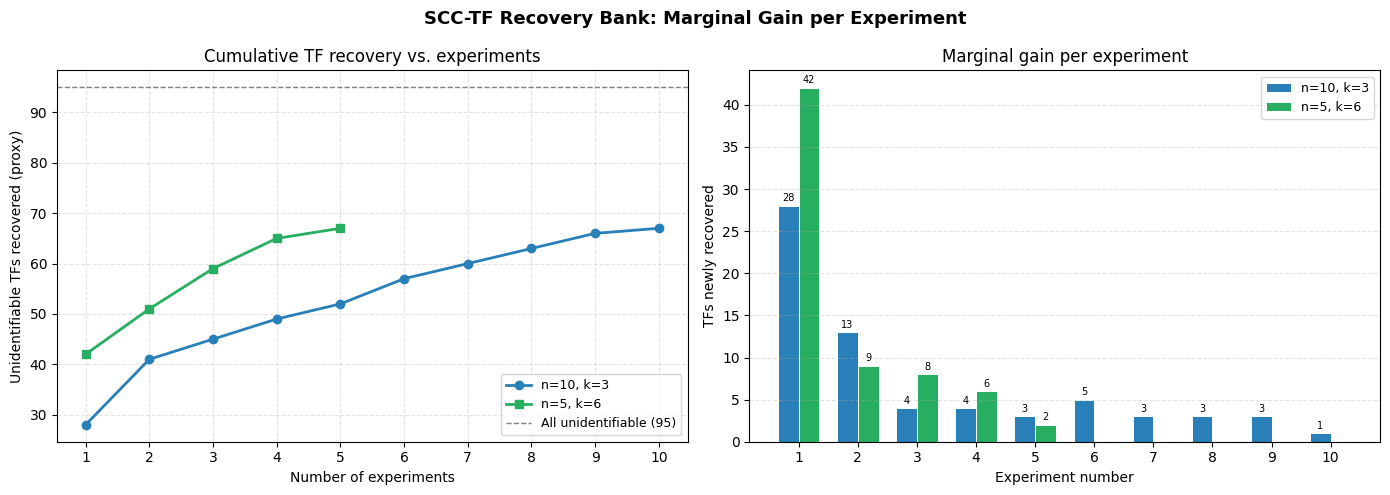

Saved: ../visualizations/scc_recovery_marginal_curve.png


In [25]:
# ── 11.2  Marginal recovery curves ────────────────────────────────────────
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

if SCC_REC_SUMMARY.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        "SCC-TF Recovery Bank: Marginal Gain per Experiment",
        fontsize=13,
        fontweight="bold",
    )

    design_styles = {
        "n10_k3": {"label": "n=10, k=3", "color": "#2980b9", "marker": "o"},
        "n5_k6": {"label": "n=5, k=6", "color": "#27ae60", "marker": "s"},
    }

    # Left: cumulative recovery curve
    ax1 = axes[0]
    n_unid = scc_rec["n10_k3"]["n_unidentifiable_baseline"]
    for design_key, style in design_styles.items():
        d = scc_rec[design_key]
        marginal = d["marginal_curve"]
        cumulative, total = [], 0
        for v in marginal:
            total += v
            cumulative.append(total)
        x = list(range(1, len(cumulative) + 1))
        ax1.plot(
            x,
            cumulative,
            marker=style["marker"],
            color=style["color"],
            label=style["label"],
            linewidth=2,
            markersize=6,
        )

    ax1.axhline(
        n_unid,
        color="gray",
        linestyle="--",
        linewidth=1,
        label=f"All unidentifiable ({n_unid})",
    )
    ax1.set_xlabel("Number of experiments")
    ax1.set_ylabel("Unidentifiable TFs recovered (proxy)")
    ax1.set_title("Cumulative TF recovery vs. experiments")
    ax1.legend(fontsize=9)
    ax1.grid(True, linestyle="--", alpha=0.35)
    ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # Right: marginal (incremental) gain per experiment, side-by-side bars
    ax2 = axes[1]
    max_n = max(
        len(scc_rec["n10_k3"]["marginal_curve"]),
        len(scc_rec["n5_k6"]["marginal_curve"]),
    )
    bar_width = 0.35
    import numpy as np

    xs = np.arange(1, max_n + 1)

    for offset, (design_key, style) in zip([-bar_width / 2, bar_width / 2], design_styles.items()):
        marginal = scc_rec[design_key]["marginal_curve"]
        padded = marginal + [0] * (max_n - len(marginal))
        ax2.bar(
            xs + offset,
            padded,
            bar_width,
            color=style["color"],
            label=style["label"],
            edgecolor="white",
            linewidth=0.7,
        )
        for xi, v in zip(xs + offset, padded):
            if v > 0:
                ax2.text(xi, v + 0.3, str(v), ha="center", va="bottom", fontsize=7)

    ax2.set_xlabel("Experiment number")
    ax2.set_ylabel("TFs newly recovered")
    ax2.set_title("Marginal gain per experiment")
    ax2.set_xticks(xs)
    ax2.legend(fontsize=9)
    ax2.grid(axis="y", linestyle="--", alpha=0.35)

    plt.tight_layout()
    _out = _ecoli_dir / "../visualizations/scc_recovery_marginal_curve.png"
    plt.savefig(str(_out), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_out}")

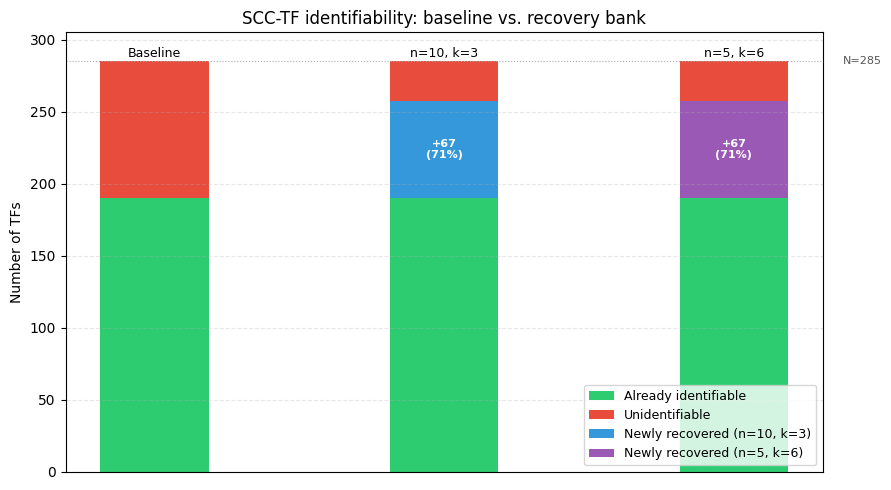

Saved: ../visualizations/scc_recovery_before_after.png


In [26]:
# ── 11.3  Before / after identifiability stacked bar ──────────────────────
import matplotlib.pyplot as plt
import numpy as np

if SCC_REC_SUMMARY.exists():
    designs = [
        ("n10_k3", "n=10, k=3"),
        ("n5_k6", "n=5, k=6"),
    ]

    fig, ax = plt.subplots(figsize=(9, 5))
    bar_width = 0.3
    xs = np.array([0, 0.8, 1.6])  # baseline + 2 designs

    d0 = scc_rec["n10_k3"]  # baseline is same for both designs
    n_total = d0["n_total_tfs"]
    n_id_base = d0["n_identifiable_baseline"]
    n_unid_base = d0["n_unidentifiable_baseline"]

    # Baseline
    ax.bar(xs[0], n_id_base, bar_width, color="#2ecc71", label="Already identifiable")
    ax.bar(xs[0], n_unid_base, bar_width, bottom=n_id_base, color="#e74c3c", label="Unidentifiable")
    ax.text(xs[0], n_total + 3, "Baseline", ha="center", fontsize=9)

    colors_rec = {"n10_k3": "#3498db", "n5_k6": "#9b59b6"}

    for xi, (design_key, label) in zip(xs[1:], designs):
        d = scc_rec[design_key]
        n_recovered = d["n_recovered"]
        n_still_unid = d["n_still_unrecovered"]
        ax.bar(xi, n_id_base, bar_width, color="#2ecc71")
        ax.bar(
            xi,
            n_recovered,
            bar_width,
            bottom=n_id_base,
            color=colors_rec[design_key],
            label=f"Newly recovered ({label})",
        )
        ax.bar(xi, n_still_unid, bar_width, bottom=n_id_base + n_recovered, color="#e74c3c")
        ax.text(xi, n_total + 3, label, ha="center", fontsize=9)

        # Annotate recovery count
        pct = n_recovered / n_unid_base * 100
        ax.text(
            xi,
            n_id_base + n_recovered / 2,
            f"+{n_recovered}\n({pct:.0f}%)",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            fontweight="bold",
        )

    ax.set_xticks([])
    ax.set_ylabel("Number of TFs")
    ax.set_title("SCC-TF identifiability: baseline vs. recovery bank", fontsize=12)
    ax.set_ylim(0, n_total + 20)
    ax.legend(fontsize=9, loc="lower right")
    ax.axhline(n_total, color="#aaa", linestyle=":", linewidth=0.8)
    ax.text(xs[-1] + 0.3, n_total, f"N={n_total}", va="center", fontsize=8, color="#555")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    _out2 = _ecoli_dir / "../visualizations/scc_recovery_before_after.png"
    plt.savefig(str(_out2), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_out2}")

In [27]:
# ── 11.4  Per-TF recovery table ───────────────────────────────────────────
import pandas as pd
from IPython.display import display

if SCC_REC_SUMMARY.exists():
    _tfs_csv = _ecoli_dir / "scc_recovery_tfs_n10_k3.csv"
    if _tfs_csv.exists():
        tfs_df = pd.read_csv(_tfs_csv)
        tfs_df = tfs_df.sort_values(["recovered", "recovered_by_set"], ascending=[False, True])

        def _style_recovered(val):
            if val is True or str(val).lower() == "true":
                return "background-color: #d5f5e3; color: #1a5276"
            elif val is False or str(val).lower() == "false":
                return "background-color: #fadbd8; color: #7b241c"
            return ""

        n_rec = (tfs_df["recovered"].astype(str).str.lower() == "true").sum()
        n_unid = len(tfs_df)
        print(
            f"Per-TF recovery table (n=10, k=3 design): "
            f"{n_rec}/{n_unid} unidentifiable TFs recovered"
        )
        display(
            tfs_df.style.map(_style_recovered, subset=["recovered"])
            .set_caption(
                "Table 3. Per-TF recovery status under the n=10, k=3 bank design.  "
                "recovered=True: at least one bank experiment breaks the TF's SCC membership.  "
                "recovered_by_set: experiment index (1-based) that first recovers this TF."
            )
            .set_table_styles(
                [{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "12px")]}]
            )
        )
    else:
        print(f"TF table not found: {_tfs_csv}")
        print("Run:  uv run python scripts/scc_recovery_bank.py --n 10 --k 3")

Per-TF recovery table (n=10, k=3 design): 67/95 unidentifiable TFs recovered


,tf,scc_size,recovered,recovered_by_set
2,acrR,68,True,1.000000
5,argP,68,True,1.000000
8,bolA,68,True,1.000000
12,csgD,68,True,1.000000
15,cytR,68,True,1.000000
19,dnaA,68,True,1.000000
23,flhC,68,True,1.000000
24,flhD,68,True,1.000000
25,fliA,68,True,1.000000
26,fliZ,68,True,1.000000


### 11.5 Comparison to CSD Edge-Level Recovery

The TF recovery bank above operates at the **TF level** — it asks which TFs transition from unidentifiable to identifiable when a set of background genes is perturbed.  The analogous analysis in `Cyclic_SingleDoor_Analysis.ipynb` (Section 7) operates at the **edge level** — it asks which individual causal edges become identifiable.

| Dimension | CSD edge-level recovery | SCC-TF recovery bank (this section) |
|---|---|---|
| Unit of recovery | Directed edge (cause → effect) | TF (whole-TF identifiability) |
| Total targets | 6,676 unidentifiable edges | 95 unidentifiable TFs |
| n=10, k=3 recovery | 6,502 / 6,676 (97.4%) | 67 / 95 (70.5%) |
| n=5, k=6 recovery | 6,502 / 6,676 (97.4%) | 67 / 95 (70.5%) |
| Ceiling | Hard: 28 unrescuable edges | Hard: 28 unrecoverable TFs |
| Algorithm | Greedy set-cover over rescue-node lists | Greedy set-cover over SCC min-cut genes |

The **28 unrecoverable TFs** (those remaining unidentifiable even after all bank experiments) correspond structurally to TFs in direct 2-cycles with in-SCC children for which no intermediate cut target exists under Interpretation A.  These are the same cut-incomplete cases identified in Phase A (§ 9.A): `tf_still_cyclic = True` even after all candidate background interventions.

**Implication for experimental design.**  The two budget configurations yield equivalent coverage.  If a smaller number of larger experiments is operationally preferred, the n=5, k=6 design achieves the same recovery with half the experimental runs, but each experiment requires knocking out 6 genes simultaneously.

### 11.6 Summary

| Metric | Value |
|---|---|
| Total TFs in E. coli network (out-degree ≥ 1) | 285 |
| Baseline identifiable (singleton SCC) | 190 (66.7%) |
| Baseline unidentifiable (non-trivial SCC) | 95 (33.3%) |
| Candidate pool (min-cut genes) | 63 unique genes |
| Recovered by n=10, k=3 bank | 67 / 95 (70.5%) |
| Recovered by n=5, k=6 bank | 67 / 95 (70.5%) |
| Identifiable after recovery | 257 / 285 (90.2%) |
| Structurally unrecoverable (under Interpretation A) | 28 / 95 |

**First experiment dominates:** under n=10, k=3, perturbation set 1 {fliZ, fur, rpoH} recovers 28 TFs alone; under n=5, k=6, set 1 {fliZ, fur, gadW, hns, rpoD, rpoH} recovers 42 TFs.

**Diminishing returns are steep:** ≥ 70% of recoverable TFs are obtained in the first 2 experiments of either design.

See `scripts/scc_recovery_bank.py`, `tests/test_scc_recovery_bank.py`, and `scripts/smoke_scc_recovery.py` for implementation and tests.

---
## References

1. **nocap** — *Network Optimization and Causal Analysis of Perturb-seq*. This repository.
2. **y0** — *Python library for causal inference under the do-calculus*. https://github.com/y0-causal-inference/y0
3. Shpitser, I. & Pearl, J. (2006). Identification of joint interventional distributions in recursive semi-Markovian causal models. *AAAI*, 21, 1219–1226.
4. Ilya Shpitser, Karthika Mohan, Judea Pearl (2015). Missing Data as a Causal and Probabilistic Problem.
5. **RegulonDB** — *E. coli* transcriptional regulatory network. Santos-Zavaleta et al. (2019). *Nucleic Acids Research*, 47(D1), D212–D220.
6. Forré, P. & Mooij, J. M. (2019). __Causal Calculus in the Presence of Cycles, Latent Confounders and Selection Bias.__ *Proceedings of the 35th Conference on Uncertainty in Artificial Intelligence (UAI)*, PMLR 115:71–80.
